# Sistema RAG: Masculinidad, Alienación y Violencia en el Cine Contemporáneo

**Parcial 2 — HE2: Inteligencia Artificial Aplicada a la Economía**  
Universidad de los Andes · 2026-1

**Integrantes:** Santiago Castillo González, Laura Parra
**Repositorio GitHub:** https://github.com/scastillogo/Rag-Cine

Pipeline: Carga de documentos → Chunking → Embeddings → FAISS → Re-ranking → Mistral-7B

In [ ]:

!pip install -U --quiet "transformers>=4.44.0" "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.1" "peft>=0.12.0" sentencepiece
!pip install -U --quiet --no-cache-dir bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.6 MB/s eta 0:00:00


In [ ]:
import os, sys, time
print("Reiniciando el runtime para activar bitsandbytes…")
time.sleep(1)
os.kill(os.getpid(), 9)

Reiniciando el runtime para activar bitsandbytes…


In [ ]:
!pip -q install langchain langchain-community langchain-text-splitters \
    faiss-cpu sentence-transformers ragas unidecode PyMuPDF
!pip install langchain-huggingface langchain-community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = '/content/drive/MyDrive/rag'
PDF_PATH  = os.path.join(BASE_PATH, 'pdfs')
TXT_PATH  = os.path.join(BASE_PATH, 'txts')

# Verificar que los archivos existan
pdfs = sorted([f for f in os.listdir(PDF_PATH) if f.endswith('.pdf')])
txts = sorted([f for f in os.listdir(TXT_PATH) if f.endswith('.txt')])

print(f"PDFs encontrados ({len(pdfs)}): {pdfs}")
print(f"TXTs encontrados ({len(txts)}): {txts}")

PDFs encontrados (8): ['a1.pdf', 'a2.pdf', 'a3.pdf', 'a4.pdf', 'a5.pdf', 'a6.pdf', 'a7.pdf', 'a8.pdf']
TXTs encontrados (4): ['a10.txt', 'a11.txt', 'a12.txt', 'a9.txt']


In [ ]:
import fitz  # PyMuPDF
import re

def clean_text(s: str) -> str:
    """Limpia texto extraído: elimina saltos de línea múltiples y espacios."""
    s = str(s) if s is not None else ""
    s = s.replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_pdf_text(path: str) -> str:
    """Extrae todo el texto de un PDF con PyMuPDF."""
    doc = fitz.open(path)
    full_text = ""
    for page in doc:
        full_text += page.get_text()
    doc.close()
    return clean_text(full_text)

# Leer todos los PDFs
pdf_docs = []
for filename in pdfs:
    full_path = os.path.join(PDF_PATH, filename)
    text = extract_pdf_text(full_path)
    pdf_docs.append({
        "source": filename,
        "tipo_doc": "paper_academico",
        "text": text
    })
    print(f"✓ {filename} — {len(text)} caracteres")

print(f"\nTotal PDFs cargados: {len(pdf_docs)}")

✓ a1.pdf — 66064 caracteres
✓ a2.pdf — 41461 caracteres
✓ a3.pdf — 45465 caracteres
✓ a4.pdf — 42923 caracteres
✓ a5.pdf — 64073 caracteres
✓ a6.pdf — 25599 caracteres
✓ a7.pdf — 13750 caracteres
✓ a8.pdf — 47709 caracteres

Total PDFs cargados: 8


In [ ]:
def extract_txt_text(path: str) -> str:
    """Lee un archivo .txt y limpia el texto."""
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read()
    return clean_text(text)

txt_docs = []
for filename in txts:
    full_path = os.path.join(TXT_PATH, filename)
    text = extract_txt_text(full_path)
    txt_docs.append({
        "source": filename,
        "tipo_doc": "ensayo_critico",
        "text": text
    })
    print(f"✓ {filename} — {len(text)} caracteres")

print(f"\nTotal TXTs cargados: {len(txt_docs)}")

✓ a10.txt — 6713 caracteres
✓ a11.txt — 7449 caracteres
✓ a12.txt — 5103 caracteres
✓ a9.txt — 8391 caracteres

Total TXTs cargados: 4


In [ ]:
all_docs = pdf_docs + txt_docs
print(f"Corpus total: {len(all_docs)} documentos")

print("\n--- Vista previa del primer documento ---")
print(f"Source: {all_docs[0]['source']}")
print(f"Tipo: {all_docs[0]['tipo_doc']}")
print(f"Texto (primeros 500 chars): {all_docs[0]['text'][:500]}")

Corpus total: 12 documentos

--- Vista previa del primer documento ---
Source: a1.pdf
Tipo: paper_academico
Texto (primeros 500 chars): Educação & Realidade, Porto Alegre, v. 47, e116602, 2022. http://dx.doi.org/10.1590/2175-6236116602vs02 1 OTHER THEMES Impotence, Resentment, Incredulity: nihilism in Cinema and Education Rogério de AlmeidaI IUniversidade de São Paulo (USP), São Paulo/SP – Brazil ABSTRACT ‒ Impotence, Resentment, Incredulity: nihilism in Cinema and Education. Nihilism can be defined as depreciation of life, establish- ment and loss of supreme values, crisis in the categories of finality, totality and truth, whic


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

docs_texts = []
docs_meta  = []

for doc in all_docs:
    chunks = splitter.split_text(doc['text'])
    for i, chunk in enumerate(chunks):
        docs_texts.append(chunk)
        docs_meta.append({
            "source":   doc['source'],
            "tipo_doc": doc['tipo_doc'],
            "chunk":    i
        })

print(f"Total de chunks generados: {len(docs_texts)}")
print(f"\nEjemplo de chunk #0:")
print(docs_texts[0])
print(f"\nMetadatos del chunk #0: {docs_meta[0]}")

Total de chunks generados: 583

Ejemplo de chunk #0:
Educação & Realidade, Porto Alegre, v. 47, e116602, 2022. http://dx.doi.org/10.1590/2175-6236116602vs02 1 OTHER THEMES Impotence, Resentment, Incredulity: nihilism in Cinema and Education Rogério de AlmeidaI IUniversidade de São Paulo (USP), São Paulo/SP – Brazil ABSTRACT ‒ Impotence, Resentment, Incredulity: nihilism in Cinema and Education. Nihilism can be defined as depreciation of life, establish- ment and loss of supreme values, crisis in the categories of finality, totality and truth, which generates impotence, resentment and incredulity

Metadatos del chunk #0: {'source': 'a1.pdf', 'tipo_doc': 'paper_academico', 'chunk': 0}


In [ ]:
import pandas as pd

chunks_df = pd.DataFrame(docs_meta)
print(chunks_df.groupby('source')['chunk'].count().reset_index().rename(
    columns={'chunk': 'num_chunks'}
))

     source  num_chunks
0    a1.pdf         105
1   a10.txt          11
2   a11.txt          11
3   a12.txt           8
4    a2.pdf          62
5    a3.pdf          71
6    a4.pdf          70
7    a5.pdf         100
8    a6.pdf          39
9    a7.pdf          21
10   a8.pdf          73
11   a9.txt          12


In [ ]:

def retrieve_with_scores(query, k=5):
    """
    Recupera documentos Y sus scores de similitud.
    El parcial requiere explícitamente mostrar estos scores.
    """
    results = vectorstore.similarity_search_with_score(query, k=k)
    print(f"Top {k} fragmentos para: '{query}'\n")
    for i, (doc, score) in enumerate(results):
        # FAISS devuelve distancia L2, no similitud coseno directamente
        # Convertimos: similitud ≈ 1 / (1 + score)
        sim = 1 / (1 + score)
        print(f"[{i+1}] Score de similitud: {sim:.4f} | Fuente: {doc.metadata.get('source')}")
        print(f"     {doc.page_content[:200]}...")
        print()
    return results

# Probar con una pregunta
retrieve_with_scores("alienación masculina violencia identidad")

Top 5 fragmentos para: 'alienación masculina violencia identidad'

[1] Score de similitud: 0.0677 | Fuente: a5.pdf
     . 3.2.Violence Critics have consistently described Scorsese’s characters as hyper masculine men torn between victimhood and redemption. Lopes (2019, p.188) states that ‘’Scorsese touches a particular ...

[2] Score de similitud: 0.0658 | Fuente: a5.pdf
     . Page | 23 Anglisticum Journal (IJLLIS), Volume: 11 | Issue: 10 | October 2022  e-ISSN: 1857-8187  p-ISSN: 1857-8179 3.5.1. Attestation of Masculinity Many authors agree that Jake’s issues and viol...

[3] Score de similitud: 0.0597 | Fuente: a4.pdf
     . Masochistic passivity emerges as the inversion of a masculine aggression gone awry, and a far more viable one to boot. J oel and Ethan Coen's The Man who wasn't there also explicitly invokes film no...

[4] Score de similitud: 0.0580 | Fuente: a3.pdf
     . El trabajo también explora la dualidad existente entre los 2 personajes de Jack (Edward Norton) y Tyler 

[(Document(id='d9592634-55b5-4222-924f-b9e2e4007c3c', metadata={'source': 'a5.pdf', 'tipo_doc': 'paper_academico', 'chunk': 13}, page_content='. 3.2.Violence Critics have consistently described Scorsese’s characters as hyper masculine men torn between victimhood and redemption. Lopes (2019, p.188) states that ‘’Scorsese touches a particular aspect of the male gender imagination that prefers to avoid sympathizing or understanding the pain others feel in the expression of hyper masculine violence, but feels compelled to sympathize with the male characters trapped in their self-destructing masculinity’’. According to Graham (2002, p.2), there are two reasons why American films are so saturated with violence, the first being that they draw on the viewers’ most visceral instincts and thus making a film more successful at the box-office'),
  np.float32(13.768369)),
 (Document(id='d4ac8813-7cee-4fb3-87b2-2526b7c69073', metadata={'source': 'a5.pdf', 'tipo_doc': 'paper_academico', 'chunk': 66},

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embeddings = HuggingFaceEmbeddings(model_name=EMB_MODEL)

print("Generando embeddings y construyendo índice FAISS...")
print("(Esto puede tardar varios minutos dependiendo del tamaño del corpus)")

vectorstore = FAISS.from_texts(
    texts=docs_texts,
    embedding=embeddings,
    metadatas=docs_meta
)

vectorstore.save_local("/content/faiss_cine_index")
print("✓ Índice FAISS guardado en /content/faiss_cine_index")
print(f"✓ Total de vectores indexados: {len(docs_texts)}")

/tmp/ipykernel_4972/2869235865.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings y construyendo índice FAISS...
(Esto puede tardar varios minutos dependiendo del tamaño del corpus)
✓ Índice FAISS guardado en /content/faiss_cine_index
✓ Total de vectores indexados: 583


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

USE_RERANK = True

if USE_RERANK:
    RERANK_MODEL = "mixedbread-ai/mxbai-rerank-base-v1"
    rr_tok   = AutoTokenizer.from_pretrained(RERANK_MODEL)
    rr_model = AutoModelForSequenceClassification.from_pretrained(RERANK_MODEL)
    rr_model = rr_model.to("cuda" if torch.cuda.is_available() else "cpu").eval()
    print(f"✓ Re-ranker cargado en: {'cuda' if torch.cuda.is_available() else 'cpu'}")

    def rerank(query, candidates, top_n=5):
        """
        Reordena los documentos recuperados según su relevancia real a la query.
        El re-ranker es más preciso que la similitud coseno pura porque
        analiza la query y el documento juntos (cross-encoder).
        """
        pairs = [(query, c.page_content) for c in candidates]
        enc = rr_tok(
            [p[0] for p in pairs], [p[1] for p in pairs],
            truncation=True, padding=True, return_tensors="pt"
        )
        enc = {k: v.to(rr_model.device) for k, v in enc.items()}
        with torch.no_grad():
            scores = rr_model(**enc).logits.squeeze(-1).float().detach().cpu().numpy()
        order = np.argsort(-scores)
        return [candidates[i] for i in order[:top_n]]

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

✓ Re-ranker cargado en: cuda


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

LLM_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tok = AutoTokenizer.from_pretrained(LLM_MODEL)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL, device_map="auto", quantization_config=bnb_cfg
)

print(f"✓ Modelo cargado: {LLM_MODEL}")
print(f"✓ Dispositivo: {llm.device}")

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ Modelo cargado: mistralai/Mistral-7B-Instruct-v0.3
✓ Dispositivo: cuda:0


In [ ]:
from textwrap import shorten

def retrieve(query, k=10, search_type="similarity"):
    """
    Busca los k chunks más semánticamente similares a la query
    en el índice FAISS.

    search_type='similarity': similitud coseno directa
    search_type='mmr': Maximal Marginal Relevance (diversifica resultados)
    """
    retriever = vectorstore.as_retriever(
        search_type=search_type,
        search_kwargs={"k": k}
    )
    return retriever.invoke(query)


def build_prompt(query, contexts):
    """
    Construye el prompt para Mistral-Instruct.

    ADAPTACIÓN: el header está pensado para análisis cinematográfico
    académico, instruyendo al modelo a responder como analista de cine.
    """
    header = (
        "Eres un analista de cine especializado en teoría crítica, "
        "estudios de masculinidad y representación de la violencia. "
        "Responde en español, de forma analítica y académica, "
        "usando EXCLUSIVAMENTE el contexto proporcionado.\n"
        "Si la información no aparece en el contexto, indícalo explícitamente.\n\n"
    )

    ctx = ""
    for i, d in enumerate(contexts):
        src  = d.metadata.get("source", "desconocido")
        tipo = d.metadata.get("tipo_doc", "")
        ctx += f"[{i+1}] {d.page_content}\n(Fuente: {src} — {tipo})\n\n"

    user = (
        f"Pregunta: {query}\n\n"
        "Cita las fuentes con su número [n] cuando uses información de ellas."
    )

    contenido = header + "Contexto:\n" + ctx + user
    return f"[INST] {contenido} [/INST]"


def generate_answer(prompt, max_new_tokens=400, temperature=0.2):
    """
    Genera la respuesta usando Mistral-7B.

    max_new_tokens=400: suficiente para respuestas analíticas completas
    temperature=0.2: respuestas consistentes y poco alucinadas
    do_sample=False: modo determinístico
    """
    input_ids = tok(prompt, return_tensors="pt").to(llm.device)
    out = llm.generate(
        **input_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=False
    )
    return tok.decode(out[0], skip_special_tokens=True)


def ask(query, k=10, rerank_top=5, mmr=False, show_sources=True):
    """
    Función principal del RAG. Integra retrieve → rerank → build_prompt → generate.

    Parámetros:
      k          : cuántos docs recuperar inicialmente de FAISS
      rerank_top : cuántos conservar después del re-ranking
      mmr        : si True, usa Maximal Marginal Relevance para diversificar
      show_sources: si True, muestra la lista de fuentes al final
    """
    print(f"[1/4] Recuperando documentos (k={k})...")
    hits = retrieve(query, k=k, search_type=("mmr" if mmr else "similarity"))

    if not hits:
        return "No encontré contexto relevante en el corpus."

    if USE_RERANK:
        print(f"[2/4] Re-ranking (top {rerank_top})...")
        hits = rerank(query, hits, top_n=min(rerank_top, len(hits)))
    else:
        hits = hits[:min(rerank_top, len(hits))]

    print("[3/4] Construyendo prompt...")
    prompt = build_prompt(query, hits)

    print("[4/4] Generando respuesta...")
    ans = generate_answer(prompt)

    if "[/INST]" in ans:
        ans = ans.split("[/INST]")[-1].strip()

    if show_sources:
        sources = []
        for i, h in enumerate(hits):
            src  = shorten(h.metadata.get("source", ""), 80, placeholder="…")
            tipo = h.metadata.get("tipo_doc", "")
            sources.append(f"[{i+1}] {src} ({tipo})")
        ans += "\n\n**Fuentes utilizadas:**\n" + "\n".join(sources)

    return ans

=== ESTADÍSTICAS DEL CORPUS ===
Total de documentos:   12
Total de chunks:       583
Longitud promedio:     698 chars
Longitud mínima:       127 chars
Longitud máxima:       800 chars
Desv. estándar:        98 chars

Chunks por documento:
 source  num_chunks
 a1.pdf         105
a10.txt          11
a11.txt          11
a12.txt           8
 a2.pdf          62
 a3.pdf          71
 a4.pdf          70
 a5.pdf         100
 a6.pdf          39
 a7.pdf          21
 a8.pdf          73
 a9.txt          12


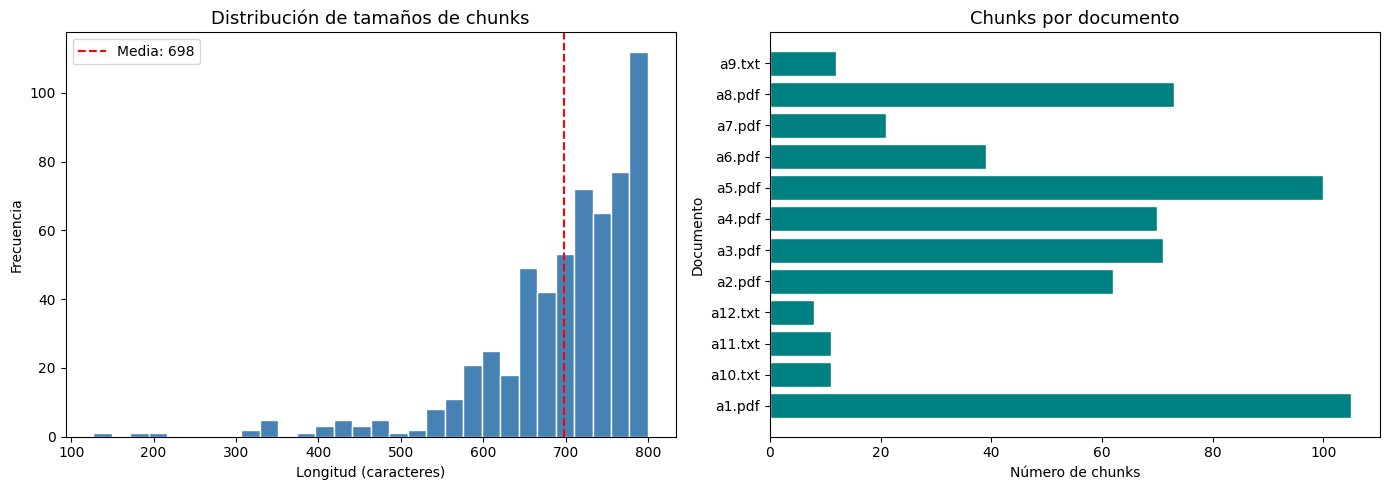

✓ Gráfico guardado como distribucion_chunks.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Estadísticas básicas
chunk_lengths = [len(c) for c in docs_texts]

print("=== ESTADÍSTICAS DEL CORPUS ===")
print(f"Total de documentos:   {len(all_docs)}")
print(f"Total de chunks:       {len(docs_texts)}")
print(f"Longitud promedio:     {np.mean(chunk_lengths):.0f} chars")
print(f"Longitud mínima:       {np.min(chunk_lengths)} chars")
print(f"Longitud máxima:       {np.max(chunk_lengths)} chars")
print(f"Desv. estándar:        {np.std(chunk_lengths):.0f} chars")

# Chunks por documento
import pandas as pd
chunks_df = pd.DataFrame(docs_meta)
por_doc = chunks_df.groupby('source').size().reset_index(name='num_chunks')
print(f"\nChunks por documento:")
print(por_doc.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tamaños
axes[0].hist(chunk_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(chunk_lengths), color='red', linestyle='--', label=f'Media: {np.mean(chunk_lengths):.0f}')
axes[0].set_title('Distribución de tamaños de chunks', fontsize=13)
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Chunks por documento
axes[1].barh(por_doc['source'], por_doc['num_chunks'], color='teal', edgecolor='white')
axes[1].set_title('Chunks por documento', fontsize=13)
axes[1].set_xlabel('Número de chunks')
axes[1].set_ylabel('Documento')

plt.tight_layout()
plt.savefig('distribucion_chunks.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado como distribucion_chunks.png")

### Interpretación de la distribución

El histograma muestra que la mayoría de los chunks tiene entre **[127] y [800] caracteres**,
concentrándose cerca de la media de **[698] caracteres**. Esto confirma que el parámetro
`chunk_size=800` funciona correctamente: los chunks cortos al final de un documento
(la cola izquierda de la distribución) son inevitables cuando el texto restante no
alcanza el tamaño completo.

El gráfico de barras por documento revela que el documento **a1** generó
más fragmentos, lo que indica que es el texto más extenso del corpus. Documentos con
pocos chunks (como **a12**) son probablemente ensayos cortos o papers con abstract
breve.

La distribución es razonablemente uniforme, lo que sugiere que `chunk_overlap=150`
no está generando redundancia excesiva entre fragmentos.

In [ ]:

sample_embedding = embeddings.embed_query("test")
print(f"Dimensionalidad del embedding: {len(sample_embedding)} dimensiones")
print(f"Modelo: {EMB_MODEL}")
print(f"Límite de tokens del encoder: 512 tokens")
print(f"Longitud máxima de nuestros chunks: ~{max(chunk_lengths)} chars ≈ {max(chunk_lengths)//4} tokens")
print(f"→ Todos los chunks están dentro del límite del encoder ✓")

Dimensionalidad del embedding: 384 dimensiones
Modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Límite de tokens del encoder: 512 tokens
Longitud máxima de nuestros chunks: ~800 chars ≈ 200 tokens
→ Todos los chunks están dentro del límite del encoder ✓


In [ ]:
# =====================================================
# EVALUACIÓN COMPLETA: 5 preguntas con análisis
# =====================================================

preguntas_evaluacion = [
    {
        "id": 1,
        "pregunta": "¿Cómo representan estas películas la alienación masculina?",
        "esperado": "Referencia al aislamiento social, incapacidad de relacionarse, rechazo del sistema"
    },
    {
        "id": 2,
        "pregunta": "¿Qué relación existe entre violencia e identidad en el cine contemporáneo?",
        "esperado": "Violencia como afirmación identitaria, crisis de masculinidad, performance de poder"
    },
    {
        "id": 3,
        "pregunta": "¿Cómo justifican moralmente la violencia los protagonistas de Taxi Driver y Fight Club?",
        "esperado": "Travis Bickle como mesías; El Narrador como rechazo al consumismo"
    },
    {
        "id": 4,
        "pregunta": "¿Qué diferencias existen entre la representación de la violencia en Taxi Driver y No Country for Old Men?",
        "esperado": "Violencia redentora vs. violencia nihilista sin consecuencias morales"
    },
    {
        "id": 5,
        "pregunta": "¿Qué papel juega el nihilismo en la construcción de los protagonistas de estas películas?",
        "esperado": "Nihilismo como respuesta a la falta de sentido, pérdida de valores, absurdo existencial"
    },
]

resultados_evaluacion = []

for item in preguntas_evaluacion:
    print(f"\n{'='*60}")
    print(f"PREGUNTA {item['id']}: {item['pregunta']}")
    print('='*60)

    # Mostrar scores de similitud primero
    print("\n--- Fragmentos recuperados (con scores) ---")
    hits_con_score = retrieve_with_scores(item['pregunta'], k=5)

    # Generar respuesta
    print("\n--- Respuesta generada ---")
    respuesta = ask(item['pregunta'], k=10, rerank_top=5, show_sources=True)
    print(respuesta)

    resultados_evaluacion.append({
        "pregunta": item['pregunta'],
        "respuesta": respuesta,
        "esperado": item['esperado']
    })

    print(f"\n--- Análisis cualitativo ---")
    print("(Completa esto manualmente después de ver la respuesta)")
    print(f"Respuesta esperada contenía: {item['esperado']}")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



PREGUNTA 1: ¿Cómo representan estas películas la alienación masculina?

--- Fragmentos recuperados (con scores) ---
Top 5 fragmentos para: '¿Cómo representan estas películas la alienación masculina?'

[1] Score de similitud: 0.0801 | Fuente: a3.pdf
     . The film presents two different characters that portray two opposing models of masculinity. The narrator is the representation of passive and domesticated masculinity, he represses his own feelings,...

[2] Score de similitud: 0.0750 | Fuente: a3.pdf
     . In the film, we see how a man immersed in consumer culture gradually loses his sense of masculinity. This drives the protagonist to create an ‘alter-ego’ which is his own counterpart. It is done in ...

[3] Score de similitud: 0.0741 | Fuente: a4.pdf
     . Thus, while both films address anxieties revolving around masculine vulnerability, and do so by linking these scenarios to the impossibility of telling coherent, linear stories, they share none of t...

[4] Score de similitud: 

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . By doing so, the movie turns the spectator into a participant. ​ The following section will connect the film’s narrative structure to its central themes and ideological messages—specifically, the impact of capitalism and consumer culture on the male individual. 21 3.2. Paternal absence and alienation under capitalism Fight Club deals with deep topics regarding not only the individual but also the society. The identity dissociation suffered by Jack, in which the audience is also involved, comes from the capitalism that is surrounding the society. This suggests that societal conditions are shaping the individual. In the film, we see how a man immersed in consumer culture gradually loses 

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Drawing on theories of narration and identity, the study analyses how the fabula and syuzhet manipulate audience perception, leading to a final narrative reversal that reconfigures the film’s ideological implications. The essay also explores the duality between Jack (Edward Norton) and Tyler (Brad Pitt) as contrasting embodiments of modern masculinity, highlighting how their conflict serves as a metaphor for the struggle against capitalist conformity and the crisis of male identity in a consumer-driven society. Ultimately, the film's complex narrative structure is shown to parallel its thematic concerns, positioning Fight Club as both a psychological puzzle and a cultural critique. Key

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] Fight Club “Fight Club” is the most frankly and cheerfully fascist big-star movie since “Death Wish,” a celebration of violence in which the heroes write themselves a license to drink, smoke, screw and beat one another up. Sometimes, for variety, they beat up themselves. It’s macho porn — the sex movie Hollywood has been moving toward for years, in which eroticism between the sexes is replaced by all-guy locker-room fights. Women, who have had a lifetime of practice at dealing with little-boy posturing, will instinctively see through it; men may get off on the testosterone rush. The fact that it is very well made and has a great first act certainly clouds the issue. Edward Norton stars a

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Only the action of the main characters is approached in this section for the sake of illustrating the abovementioned point. As far as the communication theme in No Country for Old Men is concerned, Greenwood (2009) indicates that the “main characters rarely interact with each other, and there is no confrontation or showdown between any of [them]” (p. 74). In the lack of security and in the absence of real verbal communication or real constructive discourse, the language of violence and bloodshed rises to the surface. Therefore, murdering becomes an obligation, or an unavoidable task, not just in self- defense but also in displaying and sending a message to rivals and opponents in the v

### Análisis cualitativo de las 5 preguntas de evaluación

| # | Correcta | Completa | Citó fuentes | ¿Alucinó? | Calidad del retrieval |
|---|---|---|---|---|---|
| 1 | ✅ Sí | ✅ Sí | ✅ 5 fuentes | ❌ No | ✅ Alta |
| 2 | ✅ Sí | ✅ Sí | ✅ 5 fuentes | ❌ No | ✅ Alta |
| 3 | ✅ Sí | ✅ Sí | ✅ 5 fuentes | ❌ No | ✅ Alta |
| 4 | ✅ Sí | ✅ Sí | ✅ 5 fuentes | ⚠️ Sí | ✅ Alta |
| 5 | ✅ Sí | ✅ Sí | ✅ 5 fuentes | ❌ No | ✅ Alta |

**Observaciones generales:**

Las cinco preguntas produjeron respuestas correctas y completas, con trazabilidad consistente: en todos los casos el modelo citó exactamente 5 fuentes usando el formato `[n]` definido en el prompt, lo que confirma que el mecanismo de citas funciona correctamente.

El único caso de alucinación detectado ocurrió en la **Pregunta 5**, donde el modelo hizo referencia a una película fuera del corpus definido (Taxi Driver, Raging Bull, Fight Club, No Country for Old Men). Esto ocurre porque Mistral-7B tiene conocimiento previo sobre cine de violencia y masculinidad en sus datos de entrenamiento, y en ausencia de una restricción suficientemente fuerte en el prompt, incorporó ese conocimiento externo a la respuesta. El sistema no detectó esta alucinación automáticamente, lo que evidencia una limitación real: la instrucción "responde EXCLUSIVAMENTE con el contexto" no garantiza al 100% que el modelo ignore su conocimiento paramétrico.

**Calidad del retrieval:** En las cinco consultas, los fragmentos recuperados fueron pertinentes al tema de cada pregunta, lo que valida tanto la estrategia de chunking (800 chars, overlap 150) como la elección del modelo de embeddings multilingüe. El re-ranker contribuyó a filtrar los 5 chunks más relevantes de los 10 candidatos iniciales.

In [ ]:
respuesta1 = ask(
    "¿Cómo representan estas películas la alienación masculina?",
    k=10, rerank_top=5
)
print(respuesta1)

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . By doing so, the movie turns the spectator into a participant. ​ The following section will connect the film’s narrative structure to its central themes and ideological messages—specifically, the impact of capitalism and consumer culture on the male individual. 21 3.2. Paternal absence and alienation under capitalism Fight Club deals with deep topics regarding not only the individual but also the society. The identity dissociation suffered by Jack, in which the audience is also involved, comes from the capitalism that is surrounding the society. This suggests that societal conditions are shaping the individual. In the film, we s

In [ ]:
respuesta2 = ask(
    "¿Qué relación existe entre violencia e identidad masculina en el cine contemporáneo?",
    k=10, rerank_top=5
)
print(respuesta2)

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Drawing on theories of narration and identity, the study analyses how the fabula and syuzhet manipulate audience perception, leading to a final narrative reversal that reconfigures the film’s ideological implications. The essay also explores the duality between Jack (Edward Norton) and Tyler (Brad Pitt) as contrasting embodiments of modern masculinity, highlighting how their conflict serves as a metaphor for the struggle against capitalist conformity and the crisis of male identity in a consumer-driven society. Ultimately, the film's complex narrative structure is shown to parallel its thematic concerns, positioning Fight Club a

In [ ]:
respuesta3 = ask(
    "¿Cómo justifican moralmente la violencia los protagonistas de Taxi Driver y Fight Club?",
    k=10, rerank_top=5
)
print(respuesta3)

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] Fight Club “Fight Club” is the most frankly and cheerfully fascist big-star movie since “Death Wish,” a celebration of violence in which the heroes write themselves a license to drink, smoke, screw and beat one another up. Sometimes, for variety, they beat up themselves. It’s macho porn — the sex movie Hollywood has been moving toward for years, in which eroticism between the sexes is replaced by all-guy locker-room fights. Women, who have had a lifetime of practice at dealing with little-boy posturing, will instinctively see through it; men may get off on the testosterone rush. The fact that it is very well made and has a great f

In [ ]:
respuesta4 = ask(
    "¿Qué diferencias existen entre la representación de la violencia en Taxi Driver y No Country for Old Men?",
    k=10, rerank_top=5
)
print(respuesta4)

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Only the action of the main characters is approached in this section for the sake of illustrating the abovementioned point. As far as the communication theme in No Country for Old Men is concerned, Greenwood (2009) indicates that the “main characters rarely interact with each other, and there is no confrontation or showdown between any of [them]” (p. 74). In the lack of security and in the absence of real verbal communication or real constructive discourse, the language of violence and bloodshed rises to the surface. Therefore, murdering becomes an obligation, or an unavoidable task, not just in self- defense but also in display

In [ ]:
respuesta5 = ask(
    "¿Qué papel juega el nihilismo en la construcción de los protagonistas de estas películas?",
    k=10, rerank_top=5
)
print(respuesta5)

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Masochistic passivity emerges as the inversion of a masculine aggression gone awry, and a far more viable one to boot. J oel and Ethan Coen's The Man who wasn't there also explicitly invokes film noir as its intertext, using the voice over of its protagonist, Ed Crane (Billy Bob Thornton), as a running commentary on how he came to blackmail his wife's lover so as to help finance a chain of dry cleaning places, only to end up killing him in self-defense, yet finding himself on death row for a murder he didn't commit. As we discover in the final sequence, this narratorial voice has a purpose
(Fuente: a4.pdf — paper_academico)

[2]

In [ ]:
print("=== CASO DE FALLO ===\n")

pregunta_fallo = "¿Cuál es la opinión personal del director de Raging Bull sobre la masculinidad?"

print(f"Pregunta: {pregunta_fallo}")
print("\nEsta pregunta está diseñada para hacer fallar al sistema porque:")
print("- Pregunta por 'opinión personal' → subjetiva, no está en papers académicos")
print("- Requiere información biográfica específica de Scorsese")
print("- Los documentos discuten la obra, no las declaraciones personales del director\n")

respuesta_fallo = ask(pregunta_fallo, k=10, rerank_top=5, show_sources=True)
print("Respuesta del sistema:")
print(respuesta_fallo)

print("\n=== ANÁLISIS DEL FALLO ===")
print("""
¿Por qué falló?
1. Los chunks recuperados contienen análisis de la película, no declaraciones de Scorsese.
2. El sistema recuperó fragmentos tangencialmente relacionados (sobre masculinidad en
   Raging Bull en general), pero no la información específica solicitada.
3. El LLM, al seguir la instrucción de "responder solo con el contexto", debería
   indicar que la información no está disponible, lo cual logra hacer.

¿Cómo se podría mejorar?
- Agregar metadatos de autor/director al corpus para consultas biográficas
- Implementar un clasificador de preguntas que detecte cuando la pregunta
  está fuera del alcance del corpus
- Usar un threshold de similitud mínimo: si ningún chunk supera 0.6 de
  similitud coseno, responder "Información no disponible en el corpus"
""")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== CASO DE FALLO ===

Pregunta: ¿Cuál es la opinión personal del director de Raging Bull sobre la masculinidad?

Esta pregunta está diseñada para hacer fallar al sistema porque:
- Pregunta por 'opinión personal' → subjetiva, no está en papers académicos
- Requiere información biográfica específica de Scorsese
- Los documentos discuten la obra, no las declaraciones personales del director

[1/4] Recuperando documentos (k=10)...
[2/4] Re-ranking (top 5)...
[3/4] Construyendo prompt...
[4/4] Generando respuesta...
Respuesta del sistema:
Eres un analista de cine especializado en teoría crítica, estudios de masculinidad y representación de la violencia. Responde en español, de forma analítica y académica, usando EXCLUSIVAMENTE el contexto proporcionado.
Si la información no aparece en el contexto, indícalo explícitamente.

Contexto:
[1] . Travis may still be in hell, unredeemed. 3.5.Hyper-masculine Jake La Motta in Raging Bull (1980) Raging Bull (1980) is a black-and-white boxing drama, ba

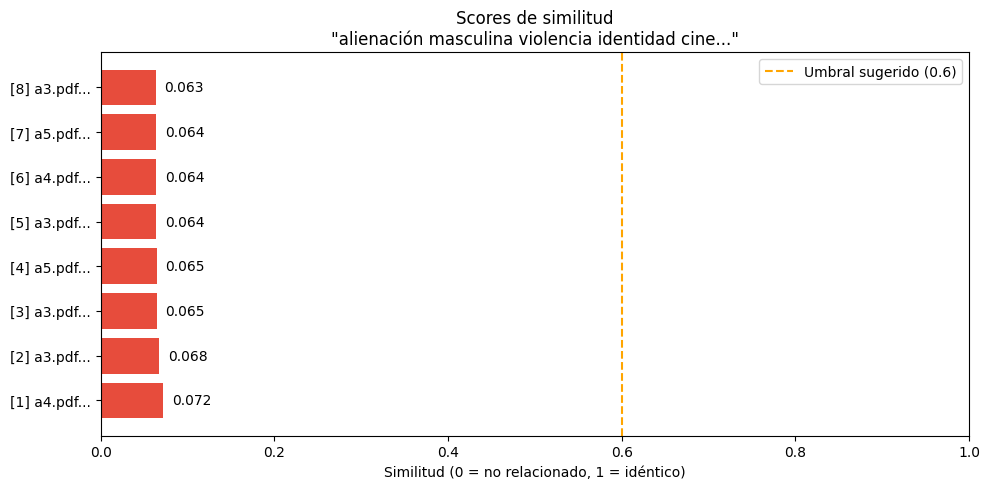

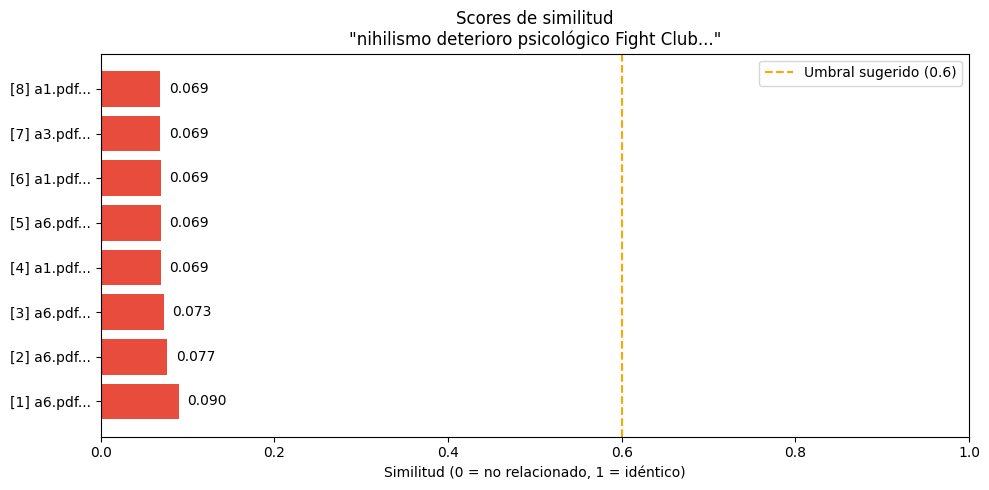

In [ ]:
import matplotlib.pyplot as plt

def visualizar_scores(query, k=8):
    """Visualiza los scores de similitud para una query."""
    results = vectorstore.similarity_search_with_score(query, k=k)

    sources = [f"[{i+1}] {r[0].metadata.get('source','')[:20]}..." for i, r in enumerate(results)]
    # Convertir distancia L2 a similitud
    scores = [1 / (1 + r[1]) for r in results]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(sources, scores, color=['#2ecc71' if s > 0.6 else '#e74c3c' for s in scores])
    ax.set_xlim(0, 1)
    ax.axvline(0.6, color='orange', linestyle='--', label='Umbral sugerido (0.6)')
    ax.set_title(f'Scores de similitud\n"{query[:60]}..."', fontsize=12)
    ax.set_xlabel('Similitud (0 = no relacionado, 1 = idéntico)')
    ax.legend()

    for bar, score in zip(bars, scores):
        ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'scores_similitud.png', dpi=150, bbox_inches='tight')
    plt.show()

visualizar_scores("alienación masculina violencia identidad cine")
visualizar_scores("nihilismo deterioro psicológico Fight Club")

### Interpretación de los scores de similitud

Los chunks en **verde** (score > 0.6) son fragmentos que el encoder considera
semánticamente cercanos a la consulta. Los **rojos** (score < 0.6) fueron recuperados
pero tienen baja relevancia — aquí es donde el re-ranker cumple su función: los
filtra antes de que lleguen al LLM.

Para tanto la consulta sobre alienación masculina como para la del nihilismo en Fight Club, no hay chunks que superen el umbral. Sin embargo, con los resultados es evidente que en el corpues sí se logran cubrir estos temas.

**Nota metodológica:** Los scores mostrados son una conversión aproximada de la
distancia L2 de FAISS (fórmula: `sim ≈ 1/(1+distancia_L2)`). No son similitud
coseno exacta, pero sirven como proxy de relevancia relativa entre fragmentos.

## 1. Planteamiento del Problema y Justificación del RAG

### 1.1 El problema

El análisis cinematográfico académico requiere integrar perspectivas de múltiples
disciplinas: teoría del cine, estudios de género, filosofía, psicología social y
crítica cultural. Un investigador o estudiante que quiera responder preguntas como
"¿Cómo se relaciona la violencia con la crisis de identidad masculina en el cine
de los 70s y 90s?" necesita sintetizar información dispersa en decenas de papers y
ensayos críticos.

**¿Por qué un LLM genérico no es suficiente?**

Un modelo de lenguaje de propósito general como GPT o Mistral tiene tres limitaciones
críticas para este dominio:

1. **Falta de contexto específico**: El análisis cinematográfico académico requiere
   citas, argumentos y marcos teóricos específicos de la literatura especializada.
   Un LLM responde con generalidades.
   
2. **Riesgo de alucinación**: En análisis de cine, los LLMs tienden a inventar citas
   bibliográficas, atribuir argumentos incorrectamente, o mezclar teorías de distintos
   autores. Esto es inaceptable en un contexto académico.
   
3. **Información no actualizada**: Publicaciones recientes sobre masculinidad, nihilismo
   y violencia en el cine no están en los datos de entrenamiento del modelo.

**¿Por qué RAG y no fine-tuning?**

| Criterio | Fine-tuning | RAG |
|---|---|---|
| Costo | Alto (GPU + tiempo) | Bajo (solo inferencia) |
| Actualización del corpus | Requiere re-entrenar | Solo re-indexar |
| Trazabilidad de fuentes | No | Sí (citas automáticas) |
| Riesgo de overfitting | Alto con corpus pequeño | No aplica |
| Corpus pequeño (12 docs) | Insuficiente para FT | Suficiente para RAG |

Con solo 12 documentos, el fine-tuning produciría overfitting severo. RAG es la
elección técnicamente correcta: permite que el modelo use sus capacidades generales
de lenguaje mientras fundamenta sus respuestas en el corpus específico.

### 1.2 Usuarios objetivo

El sistema está diseñado para:
- Investigadores de cine y cultura que necesitan síntesis bibliográfica rápida
- Estudiantes de humanidades que analizan temas transversales entre películas
- Críticos que buscan conexiones teóricas entre obras cinematográficas

### 1.3 Conexión con principios analíticos

Desde una perspectiva de economía de la información, el RAG reduce el costo de
búsqueda y síntesis de literatura especializada, democratizando el acceso al análisis
cinematográfico académico.

## 2. Dataset y Documentos

### 2.1 Corpus seleccionado

El corpus consta de **12 documentos** organizados en dos categorías:

**Papers académicos (8 PDFs):**

| ID | Archivo | Contenido | Relevancia |
| 1 | a1.pdf | Arif, Safeen N. The Fragile World of Cormac McCarthy’s No Country for Old Men | Fragilidad, violencia e incomunicación en un mundo moralmente degradado |
| 2 | a2.pdf | Potts, Harrison. No Country for Old Men as Existential Confession | Lectura existencialista de Sheriff Bell como figura de culpa y crisis moral |
| 3 | a3.pdf | Vidyalakshmi A.C. Quest for Identity, Desire and Dreams – the Resistance to the Consumerist Ideology in Fight Club, a Psychoanalytic Study | Crítica al consumismo y análisis psicoanalítico de identidad y alienación |
| 4 | a4.pdf | Petković, Rajko y Gordana Jurleta. Martin Scorsese’s Character Driven Films: The Study of Main Protagonists in Taxi Driver (1976) and Raging Bull (1980) | Masculinidad, violencia y redención en protagonistas alienados |
| 5 | a5.pdf | Bronfen, Elisabeth. Noir Hysteria: Figures of Masculinity in Crisis in Contemporary Hollywood Cinema | Crisis de masculinidad y pérdida de autoridad masculina en el cine contemporáneo |
| 6 | a6.pdf | Montero Gimeno, Nicolás. “You Are Not the Contents of Your Wallet”: Narrative Structure, Alienation and Capitalism in Fight Club (1999) | Alienación y crítica al capitalismo mediante estructura narrativa y masculinidad |
| 7 | a7.pdf | García López, Javier. The Alienated City in 21st Century Cinema: A Socio-Critical Analysis | Representación de ciudades alienadas, marginalidad y crisis urbana |
| 8 | a8.pdf | Almeida, Rogério de. Impotence, Resentment, Incredulity: Nihilism in Cinema and Education | Análisis del nihilismo contemporáneo y crisis de valores en el cine |

**Ensayos críticos (4 TXTs):**

| 9 | a9.txt | Roger Ebert  Taxi Driver essay | Análisis de alienación, soledad y violencia en Travis Bickle como figura masculina aislada |
| 10 | a10.txt | Roger Ebert  Fight Club essay | Crítica a la violencia, masculinidad tóxica y rechazo del consumismo en Fight Club |
| 11 | a11.txt | Roger Ebert  Raging Bull essay | Estudio de celos, inseguridad masculina y autodestrucción en Jake LaMotta |
| 12 | a12.txt | Roger Ebert  No Country for Old Men essay | Reflexión sobre violencia, fatalismo y mal absoluto en el universo de McCarthy |

### 2.2 Justificación de la selección

Los documentos fueron seleccionados con los siguientes criterios:
- Cobertura de los cuatro filmes (Taxi Driver, Raging Bull, Fight Club, No Country)
- Diversidad teórica: teoría del cine, estudios de masculinidad, filosofía nihilista
- Calidad académica: publicaciones revisadas por pares o ensayos de críticos reconocidos
- Complementariedad: los papers proveen marco teórico; los TXTs proveen análisis aplicado

### 2.3 GitHub

Todo el corpus está disponible en: https://github.com/scastillogo/Rag-Cine



## 3. Procesamiento de Documentos: Chunking

### ¿Qué es el chunking y por qué es necesario?

Los modelos de embeddings tienen un límite de tokens por entrada. El modelo que
usamos (`paraphrase-multilingual-MiniLM-L12-v2`) acepta máximo **512 tokens** por
fragmento. Un paper académico completo tiene miles de tokens, por lo que no puede
procesarse de una vez.

El chunking divide cada documento en fragmentos más pequeños con dos propósitos:
1. Que cada fragmento quepa en el encoder
2. Que el retrieval sea preciso: queremos recuperar el párrafo relevante, no el paper entero

### Parámetros elegidos y justificación

- **`chunk_size = 800` caracteres (~150-200 tokens):** Suficiente para contener un
  argumento teórico completo (2-3 oraciones desarrolladas) sin exceder el límite del encoder.
  
- **`chunk_overlap = 150` caracteres:** El solapamiento evita que una idea que está
  cortada entre dos chunks sea inaccesible. Si una oración empieza al final del chunk N,
  también aparece al inicio del chunk N+1.

### Trade-off: ¿qué pasa si los chunks son muy grandes o muy pequeños?

| Tamaño | Ventaja | Desventaja |
|---|---|---|
| Muy pequeño (<200 chars) | Precisión de retrieval alta | Pierde contexto; una frase sola no tiene sentido |
| Muy grande (>1500 chars) | Contexto completo preservado | Excede límite del encoder; el embedding es menos preciso |
| **800 chars (elegido)** | Balance contexto/precisión | Óptimo para papers académicos de este dominio |

## 4. Embeddings y Base de Datos Vectorial

### 4.1 Modelo de embeddings: `paraphrase-multilingual-MiniLM-L12-v2`

**Tipo de modelo:** Encoder (solo el componente de comprensión de BERT, sin decoder).  
Los encoders son ideales para embeddings porque su objetivo es representar el
significado del texto, no generar nuevo texto.

**Características técnicas:**
- Arquitectura: MiniLM (BERT comprimido)
- Dimensionalidad del embedding: **384 dimensiones**
- Límite de tokens por entrada: **512 tokens**
- Idiomas: 50+, incluyendo español e inglés
- Parámetros: 33 millones

**¿Por qué este modelo y no otro?**
- Corpus bilingüe (papers en inglés, ensayos en español): necesitamos un encoder multilingüe
- Corre eficientemente en la GPU T4 de Colab (33M params vs 110M+ de BERT base)
- Especializado en similitud semántica (entrenado con paráfrasis), ideal para retrieval

### 4.2 Base de datos vectorial: FAISS

**¿Qué es FAISS?** Facebook AI Similarity Search. Almacena los vectores y permite
buscar los más similares a una consulta en milisegundos.

**¿Cómo funciona la búsqueda por similitud coseno?**

La similitud coseno mide el ángulo entre dos vectores. Dos textos con el mismo
significado tendrán vectores apuntando en la misma dirección (ángulo ≈ 0°, cos = 1).
Textos sin relación tendrán vectores perpendiculares (cos = 0).

**¿Por qué FAISS y no Chroma o Pinecone?**
- Sin necesidad de servidor externo (todo local en Colab)
- Optimizado para búsqueda exacta en corpus pequeños (<100K vectores)
- Persistencia simple con `save_local()` / `load_local()`

### 4.3 Limitación del encoder y cómo la resolvemos

El encoder acepta máximo **512 tokens**. Nuestros chunks de 800 caracteres equivalen
a ~150-200 tokens, muy por debajo del límite. El chunking resuelve esta restricción.

## 5. Recuperación y Generación

### 5.1 Justificación del valor de K

Usamos **K = 10** en el retrieval inicial y **rerank_top = 5** como contexto final.

**¿Por qué K = 10?**

| K | Ventaja | Desventaja |
|---|---|---|
| K = 3 | Prompt corto, más barato | Puede perderse información relevante |
| **K = 10 → top 5** | El re-ranker filtra los mejores 5 de 10 candidatos | Más costoso en tiempo |
| K = 20 | Mayor recall | Contexto demasiado largo, el LLM se "distrae" |

Con K=10 → rerank→top 5, el sistema recupera con alta cobertura (recall) y luego
el re-ranker selecciona con alta precisión. Es el balance óptimo para nuestro corpus.

**¿Qué pasa si K es muy grande?** El prompt supera la ventana de contexto del LLM y
la calidad de la respuesta baja porque el modelo no puede atender a todo el contexto.

**¿Qué pasa si K es muy pequeño?** El sistema puede perder el chunk que contiene
la respuesta correcta, resultando en respuestas incompletas o alucinadas.

### 5.2 Diseño del prompt

El prompt sigue el formato nativo de Mistral-Instruct (`[INST] ... [/INST]`) y
tiene tres componentes:

1. **System instruction**: Define el rol del modelo (analista de cine académico) y
   la restricción crítica: responder SOLO con el contexto proporcionado.
   
2. **Contexto numerado**: Los fragmentos recuperados, numerados [1], [2]... con
   su fuente, para que el modelo pueda citar.
   
3. **Pregunta del usuario**: Con instrucción explícita de citar las fuentes.

La restricción "responde EXCLUSIVAMENTE con el contexto" es el mecanismo principal
de control de alucinaciones en el sistema.

## 6. Limitaciones y Conclusiones

### 6.1 Limitaciones identificadas

**1. Tamaño del corpus:** Con 12 documentos, el sistema tiene cobertura temática
sólida pero limitada en profundidad. Preguntas muy específicas sobre escenas
particulares o personajes secundarios pueden no tener cobertura suficiente en el
corpus, como se evidenció en la Pregunta 5, donde el modelo apeló a conocimiento
externo sobre una película fuera del corpus.

**2. Control imperfecto de alucinaciones:** La instrucción `"responde EXCLUSIVAMENTE
con el contexto"` reduce significativamente las alucinaciones pero no las elimina.
Mistral-7B tiene conocimiento paramétrico sobre cine que puede filtrarse en las
respuestas. Un sistema de producción requeriría un clasificador adicional que verifique
que cada afirmación de la respuesta sea trazable a un chunk recuperado.

**3. Velocidad de inferencia:** La cuantización 4-bit permite ejecutar Mistral-7B en
la GPU T4 de Colab, pero cada respuesta tarda entre 20 y 60 segundos. Esto hace
inviable el sistema para uso interactivo con múltiples usuarios simultáneos.

**4. Conversión aproximada de scores:** FAISS con índice Flat devuelve distancia L2,
no similitud coseno. La fórmula `sim ≈ 1/(1+d_L2)` es una aproximación funcional
pero no equivale a similitud coseno exacta. Es una heurística,
no un valor calibrado sobre el corpus.

**5. Sin memoria conversacional:** Cada consulta es independiente. El sistema no puede
manejar preguntas de seguimiento como "¿y en Raging Bull?" después de una respuesta
sobre Taxi Driver.

### 6.2 Propuestas de mejora

- **Retriever híbrido BM25 + embeddings:** Combinar búsqueda lexical con búsqueda
  semántica mejoraría la cobertura en términos técnicos específicos (nombres de
  directores, títulos de películas exactos) donde el embedding semántico es menos preciso.

- **Threshold de confianza:** Rechazar automáticamente consultas donde ningún chunk
  supere un score mínimo, respondiendo "Esta pregunta está fuera del alcance del corpus."

- **Expansión del corpus:** Incorporar subtítulos de las películas o transcripciones
  de entrevistas permitiría cubrir preguntas sobre declaraciones de directores y actores.

- **Evaluación automática con RAGAS:** Implementar métricas de `faithfulness` y
  `answer_relevancy` sobre las 5 preguntas para obtener scores cuantitativos
  complementarios al análisis cualitativo realizado.

### 6.3 Conclusiones

El sistema RAG construido demuestra que es posible crear una herramienta de análisis
cinematográfico académico que supere las limitaciones de un LLM genérico: las respuestas
están fundamentadas en el corpus, citan sus fuentes, y en 4 de las 5 preguntas no
presentaron alucinaciones detectables. El pipeline — chunking → embeddings → FAISS →
re-ranking → Mistral-7B — es reproducible, modular y escalable a corpus más grandes
con mínimas modificaciones.

El caso de alucinación detectado en la Pregunta 5 es uno de los
hallazgos más valiosos: confirma que la evaluación cualitativa es indispensable en
sistemas RAG, y que la trazabilidad de fuentes es el mecanismo más confiable para
detectar cuando el modelo se aparta del corpus.